## California Housing Prices (regression), dataset evaluation report 
#### (https://www.kaggle.com/datasets/camnugent/california-housing-prices)<br>Target variable is "median_house_value" (continuous, regression).<br>Price range is 14 999 - 500 001 USD.

### Variables to drop or to process further<br>
- longitude, latitude - will be dropped as coordinates are not good for ML model (based on coordinates I created a new column "distance_to_nearest_city" to use in the evaluation)<br>
- ocean_proximity - categorical variable. Will be processed using encoder.<br>

#### This is the path to dataset preparation file: Exercise_project_1\Regression_dataset\dataset preparation.ipynb


### Rest of the variables

- "housing_median_age",
- 'total_rooms', 
- 'total_bedrooms', 
- 'population',
- 'households', 
- 'median_income',


###  Variable importance and redundancy analysis, missing values

#### According to ydata-profiling there are missing values in "total_bedrooms" variable. As we have 20640 of rows we can just drop rows with missing value.<br>VIF-test for multicollinearity<br>median_house_value has positive correlation with "median_income" and negative correlation with "ocean_proximity_INLAND" and "distance_to_nearest_city" (Source: dataset_preparation.ipynb)<br>Based on correlation matrix and VIF test there is multicollinearity + redundancy: total_rooms, total_bedrooms, and households, population:
- total_rooms and total_bedrooms : these two are strongly linearly related — houses with more rooms usually have more bedrooms.<br>
- households and  population: population ≈ households× avg_people_per_household - these two variables carry kinda similar information and they produce high correlation and high VIF
- ocean_proximity_<1H OCEAN and ocean_proximity_INLAND: These are one-hot encoded variables.

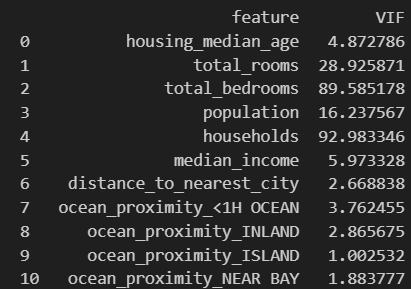 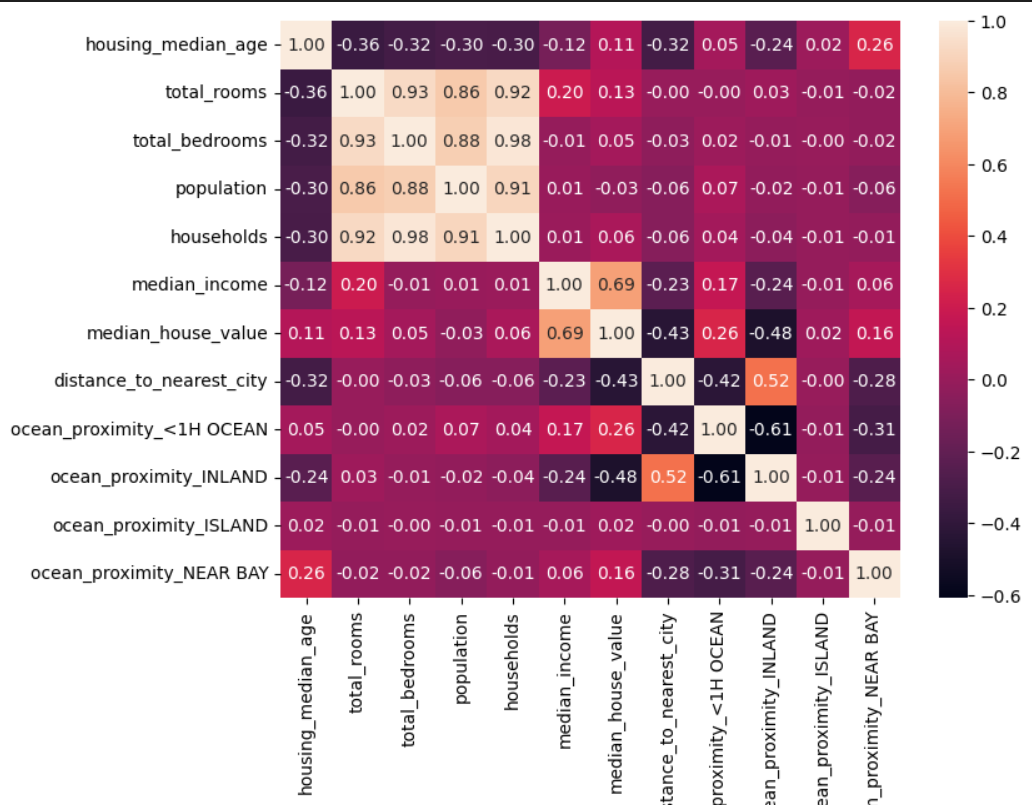

#### Options to do:
- drop "total_bedrooms" and preserve "total_rooms". Also drop "households" and preserve "population". And we can cosider to remove one encoded variable, for example one with highest VIF-test score "ocean_proximity_<1H OCEAN"
- we can combine variables: "rooms_per_household" = "total_rooms" /"households"
"bedroom_share" = "total_bedrooms" / "total_rooms", "population_per_household" = "population" / "households" (basically this would tell How many people live in an average household?)

### Distributions

#### Target variable (median_house_value) distribution. Not a normal distribution.
- Most houses are clustered between 100,000–250,000.
- we can seee a huge spike at 500,001, probably the “luxury” tail of the price distribution is compressed into one single value. Actually, the dataset hides the true prices of expensive houses. This is bad for ML model because a model will never predict values much higher than 500,001

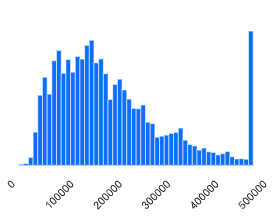

#### Fix options:
- use quantiles to remove the top % in order to get closer to normal distribution
- Offered but ChatGPT: Log transformation, Winsorization (capping extreme values instead of deleting), Robust scaling (for ML models), Box–Cox or Yeo–Johnson transformations

### Support variable distributions